In [109]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
from prophet.plot import plot_plotly

In [111]:
covid_data=pd.read_csv(r"C:\Users\ANURAG\Desktop\Intellipat\Capstone Projects\COVID 19\Project-COVID-19-Analysis-1\covid_19_clean_complete.csv")
                       

In [113]:
covid_data

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,22-01-2020,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,22-01-2020,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,22-01-2020,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,22-01-2020,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,22-01-2020,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,27-07-2020,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,27-07-2020,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,27-07-2020,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,27-07-2020,7235,60,6028,1147,Europe


In [115]:
covid_data.shape

(49068, 10)

In [117]:
covid_data=covid_data.drop(columns=['Province/State'])

In [119]:
covid_data.head()

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.93911,67.709953,22-01-2020,0,0,0,0,Eastern Mediterranean
1,Albania,41.15330,20.168300,22-01-2020,0,0,0,0,Europe
2,Algeria,28.03390,1.659600,22-01-2020,0,0,0,0,Africa
3,Andorra,42.50630,1.521800,22-01-2020,0,0,0,0,Europe
4,Angola,-11.20270,17.873900,22-01-2020,0,0,0,0,Africa


In [121]:
covid_data=covid_data.drop(columns=['Lat','Long'],axis=1)

In [123]:
covid_data.head()

,Country/Region,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,22-01-2020,0,0,0,0,Eastern Mediterranean
1,Albania,22-01-2020,0,0,0,0,Europe
2,Algeria,22-01-2020,0,0,0,0,Africa
3,Andorra,22-01-2020,0,0,0,0,Europe
4,Angola,22-01-2020,0,0,0,0,Africa


In [125]:
covid_data['Date'] = pd.to_datetime(covid_data['Date'])

C:\Users\ANURAG\AppData\Local\Temp\ipykernel_19292\3902955790.py:1: UserWarning:

Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.



In [128]:
global_trend = covid_data.groupby('Date')[['Confirmed','Deaths','Active', 'Recovered']].sum().reset_index()

In [130]:
global_trend.head()


,Date,Confirmed,Deaths,Active,Recovered
0,2020-01-22,555,17,510,28
1,2020-01-23,654,18,606,30
2,2020-01-24,941,26,879,36
3,2020-01-25,1434,42,1353,39
4,2020-01-26,2118,56,2010,52


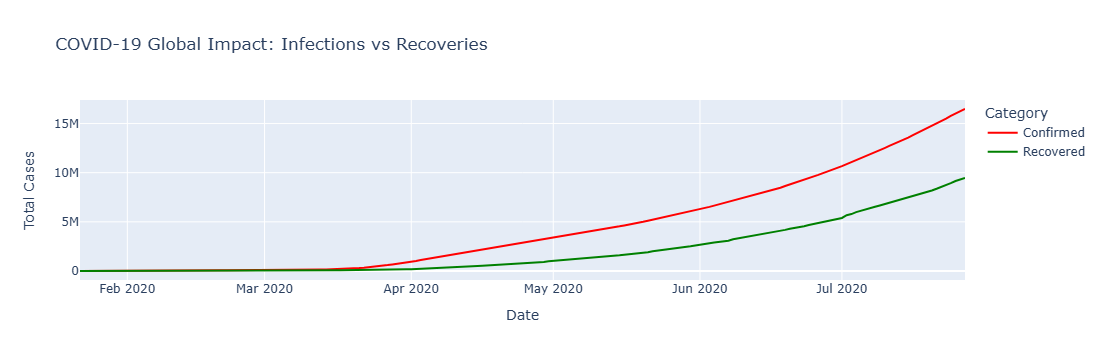

In [132]:
fig1 = px.line(global_trend, x='Date', y=['Confirmed', 'Recovered'], 
              title='COVID-19 Global Impact: Infections vs Recoveries',
              labels={'value': 'Total Cases', 'variable': 'Category'},
              color_discrete_map={'Confirmed': 'red', 'Recovered': 'green'})
fig1.show()

In [134]:
global_trend['Daily_Infections'] = global_trend['Confirmed'].diff().fillna(0)
global_trend['Daily_Recoveries'] = global_trend['Recovered'].diff().fillna(0)


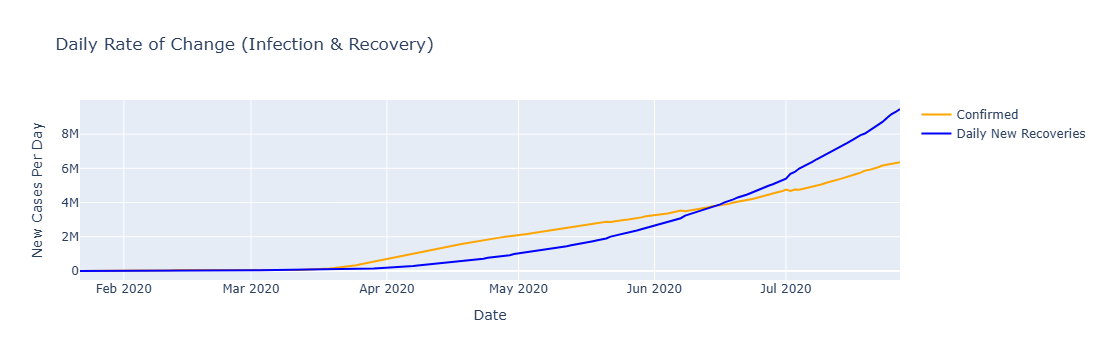

In [136]:
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=global_trend['Date'], y=global_trend['Active'], 
                         name='Confirmed', line=dict(color='orange')))
fig2.add_trace(go.Scatter(x=global_trend['Date'], y=global_trend['Recovered'], 
                         name='Daily New Recoveries', line=dict(color='blue')))
fig2.update_layout(title='Daily Rate of Change (Infection & Recovery)',
                  xaxis_title='Date', yaxis_title='New Cases Per Day')
fig2.show()

In [144]:
predict_df = global_trend[['Date', 'Confirmed']].rename(columns={'Date': 'ds', 'Confirmed': 'y'})

model = Prophet(interval_width=0.95, daily_seasonality=False)
model.fit(predict_df)



13:41:06 - cmdstanpy - INFO - Chain [1] start processing
13:41:07 - cmdstanpy - INFO - Chain [1] done processing


In [148]:
future = model.make_future_dataframe(periods=7)
forecast = model.predict(future)
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7))

            ds          yhat    yhat_lower    yhat_upper
188 2020-07-28  1.632401e+07  1.616292e+07  1.647649e+07
189 2020-07-29  1.653405e+07  1.637758e+07  1.668433e+07
190 2020-07-30  1.674820e+07  1.659646e+07  1.691959e+07
191 2020-07-31  1.696362e+07  1.680172e+07  1.712804e+07
192 2020-08-01  1.717143e+07  1.700292e+07  1.734470e+07
193 2020-08-02  1.736922e+07  1.719026e+07  1.754535e+07
194 2020-08-03  1.756410e+07  1.739556e+07  1.775584e+07


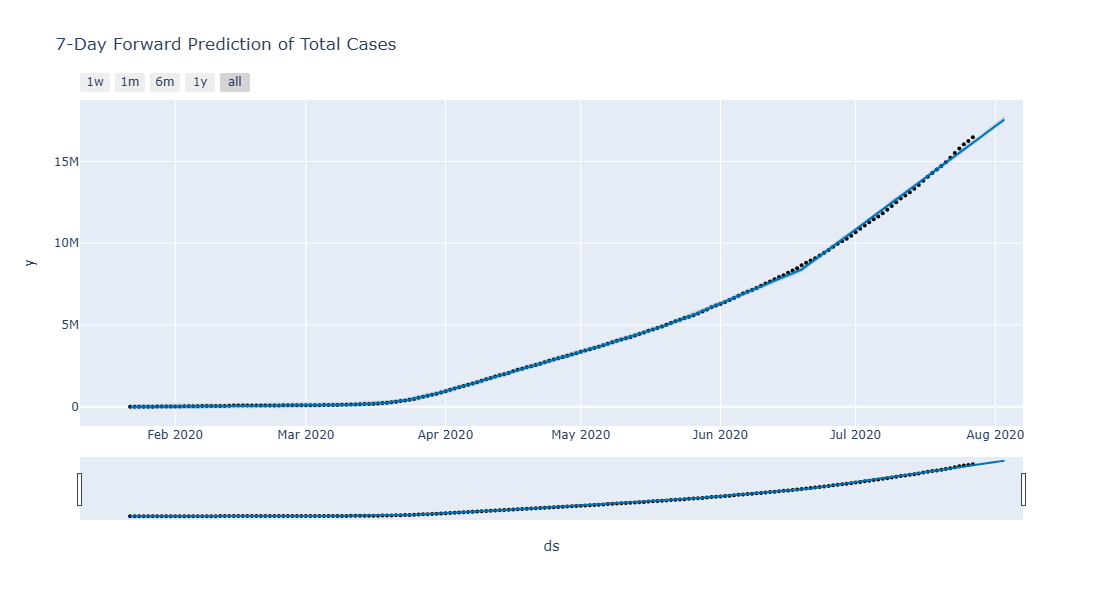

In [150]:
fig3 = plot_plotly(model, forecast)
fig3.update_layout(title='7-Day Forward Prediction of Total Cases')
fig3.show()